# 05 — SHAP Analysis: Explainability & Ethical Conclusion

**Objetivo**: entender o que cada modelo aprendeu via SHAP values, comparar
o ranking de features entre o modelo financeiro e o emocional, e chegar a
uma recomendação ética documentada.

**SHAP (SHapley Additive exPlanations)**: cada feature recebe um valor que
representa sua contribuição *aditiva* para a previsão de cada instância.
Ao contrário de feature importance baseada em ganho (que é global), SHAP
é local (por instância) e direcional (sinal positivo = aumenta risco).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.data.split import load_splits
from src.data.emotional import inject_emotional_features, EMOTIONAL_FEATURES
from src.explainability.shap_explainer import CreditExplainer

plt.rcParams["figure.dpi"] = 100
MODELS_DIR = PROJECT_ROOT / "models"

splits = load_splits(PROJECT_ROOT / "data" / "processed")
train, val, test = splits["train"], splits["val"], splits["test"]

FINANCIAL_FEATURES = [c for c in train.columns if c != "target"]
ALL_FEATURES = FINANCIAL_FEATURES + EMOTIONAL_FEATURES

# Adicionar features emocionais aos splits
val_e  = inject_emotional_features(val,  random_state=42)
test_e = inject_emotional_features(test, random_state=42)

# Carregar modelos
model_fin = joblib.load(MODELS_DIR / "xgboost_financial.pkl")
model_emo = joblib.load(MODELS_DIR / "xgboost_emotional.pkl")

print("Modelos carregados.")
print(f"Financial features: {len(FINANCIAL_FEATURES)}")
print(f"All features (with emotional): {len(ALL_FEATURES)}")

Modelos carregados.
Financial features: 11
All features (with emotional): 15


## 1. SHAP Summary Plot — Modelo Financeiro

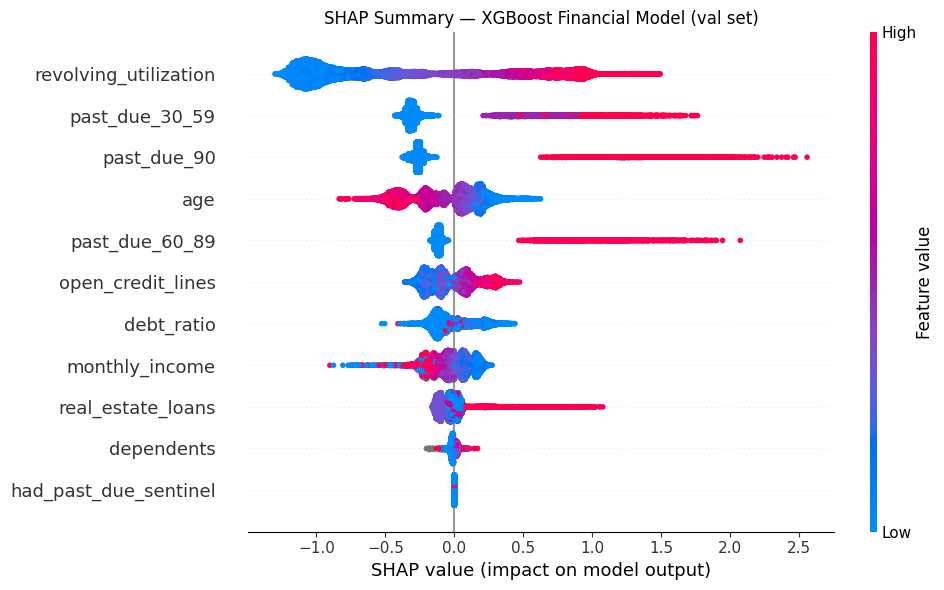

In [2]:
X_val_fin = val[FINANCIAL_FEATURES].astype("float64")
explainer_fin = shap.TreeExplainer(model_fin)
shap_vals_fin = explainer_fin.shap_values(X_val_fin)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_fin, X_val_fin, feature_names=FINANCIAL_FEATURES,
                  show=False, plot_size=(10, 6))
plt.title("SHAP Summary — XGBoost Financial Model (val set)")
plt.tight_layout()
plt.show()

**Como ler**: cada linha é uma feature. Os pontos representam instâncias da
validação. A cor indica o valor da feature (azul=baixo, vermelho=alto).
A posição x indica o impacto na previsão: positivo = aumenta risco de default.

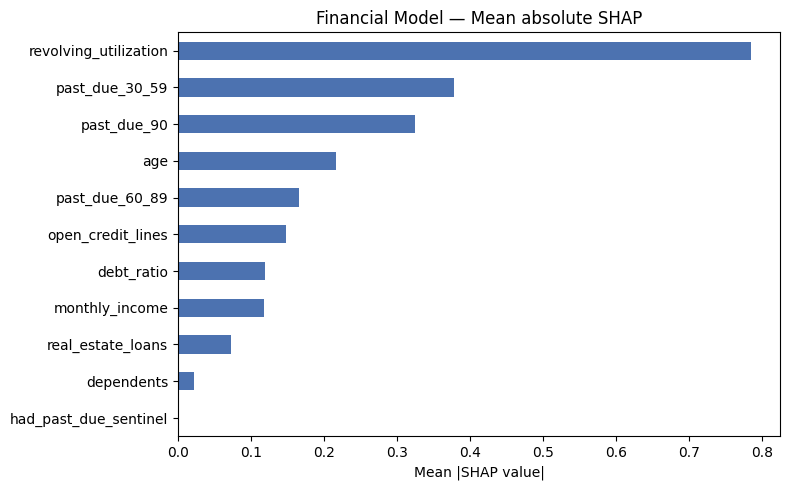

In [3]:
# Feature importance media absoluta
mean_abs_fin = pd.Series(
    np.abs(shap_vals_fin).mean(axis=0),
    index=FINANCIAL_FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
mean_abs_fin.plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Financial Model — Mean absolute SHAP")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 2. SHAP Summary Plot — Modelo Emocional

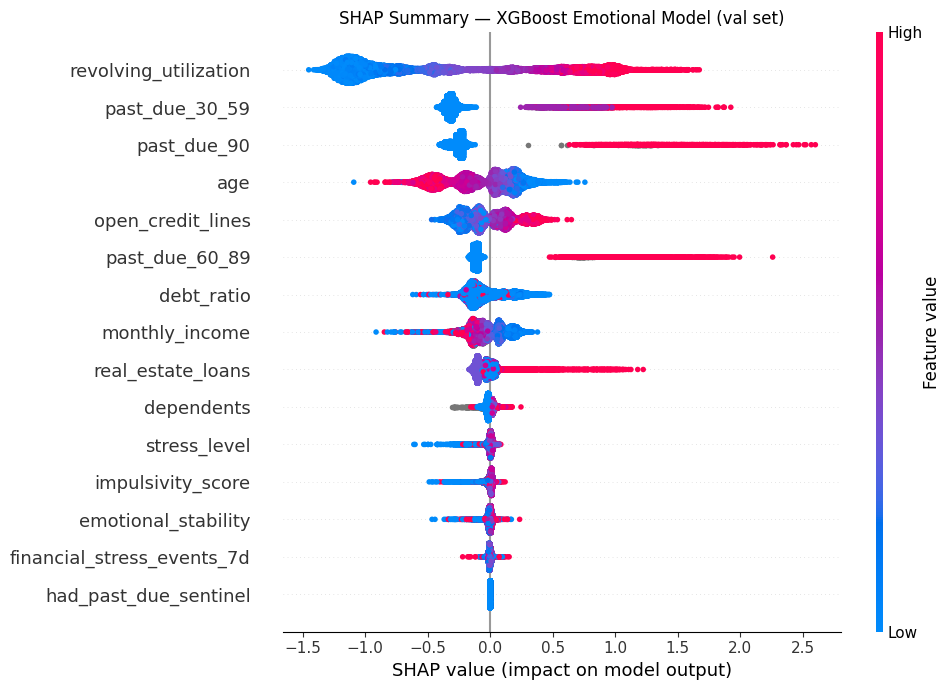

In [4]:
X_val_emo = val_e[ALL_FEATURES].astype("float64")
explainer_emo = shap.TreeExplainer(model_emo)
shap_vals_emo = explainer_emo.shap_values(X_val_emo)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_emo, X_val_emo, feature_names=ALL_FEATURES,
                  show=False, plot_size=(10, 7))
plt.title("SHAP Summary — XGBoost Emotional Model (val set)")
plt.tight_layout()
plt.show()

## 3. Comparação: Ranking de Features Financial vs Emotional

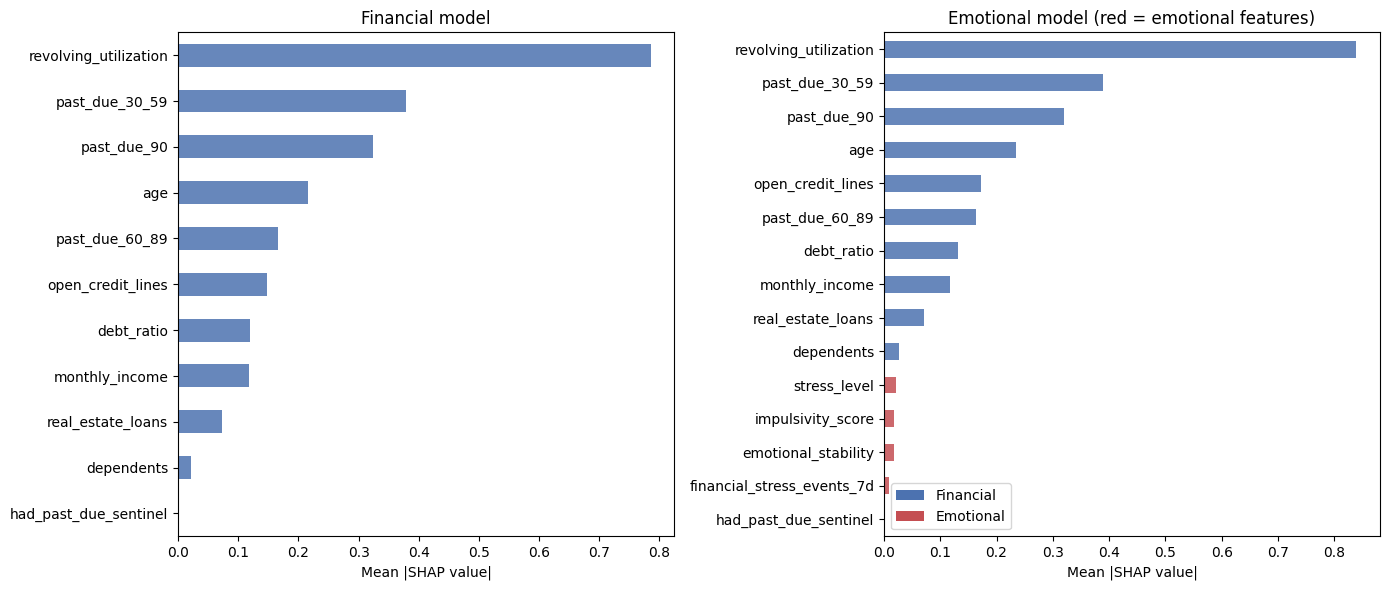

Emotional features: 0.0658 (2.6% do total SHAP)
Financial features: 2.4645 (97.4% do total SHAP)


In [5]:
mean_abs_emo = pd.Series(
    np.abs(shap_vals_emo).mean(axis=0),
    index=ALL_FEATURES
).sort_values(ascending=False)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mean_abs_fin.plot.barh(ax=axes[0], color="#4C72B0", alpha=0.85)
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("Financial model")
axes[0].invert_yaxis()

colors_emo = ["#C44E52" if f in EMOTIONAL_FEATURES else "#4C72B0"
              for f in mean_abs_emo.index]
mean_abs_emo.plot.barh(ax=axes[1], color=colors_emo, alpha=0.85)
axes[1].set_xlabel("Mean |SHAP value|")
axes[1].set_title("Emotional model (red = emotional features)")
axes[1].invert_yaxis()

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor="#4C72B0", label="Financial"),
    Patch(facecolor="#C44E52", label="Emotional"),
])

fig.tight_layout()
plt.show()

# Quanto as emocionais contribuem no modelo emocional?
emo_contrib = mean_abs_emo[EMOTIONAL_FEATURES].sum()
fin_contrib = mean_abs_emo[FINANCIAL_FEATURES].sum()
print(f"Emotional features: {emo_contrib:.4f} ({emo_contrib/(emo_contrib+fin_contrib):.1%} do total SHAP)")
print(f"Financial features: {fin_contrib:.4f} ({fin_contrib/(emo_contrib+fin_contrib):.1%} do total SHAP)")

## 4. SHAP Waterfall — Explicação Individual

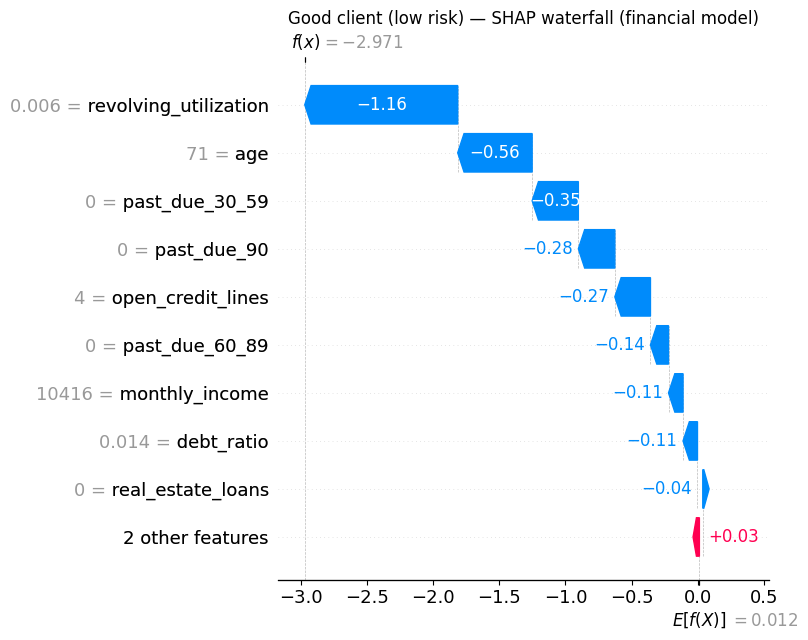

  Predicted probability: 0.0488, Actual: 0



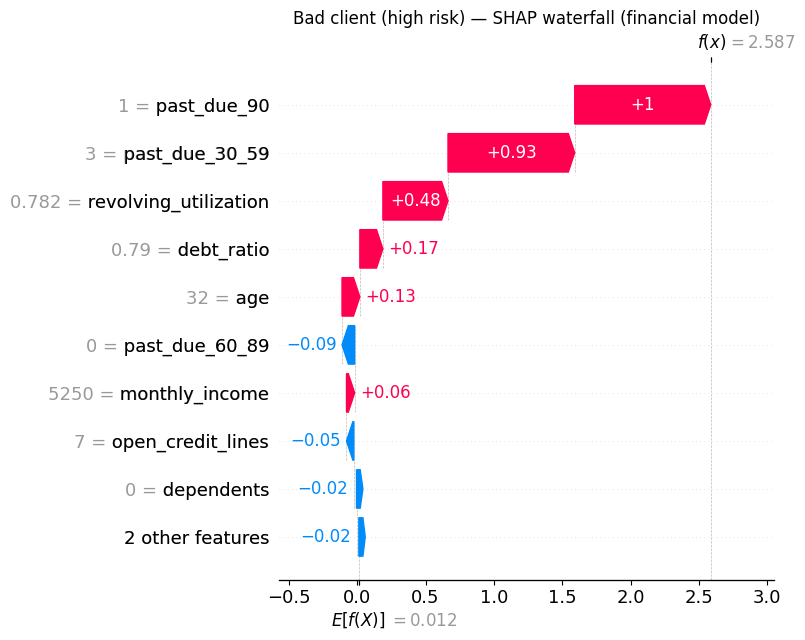

  Predicted probability: 0.9300, Actual: 1



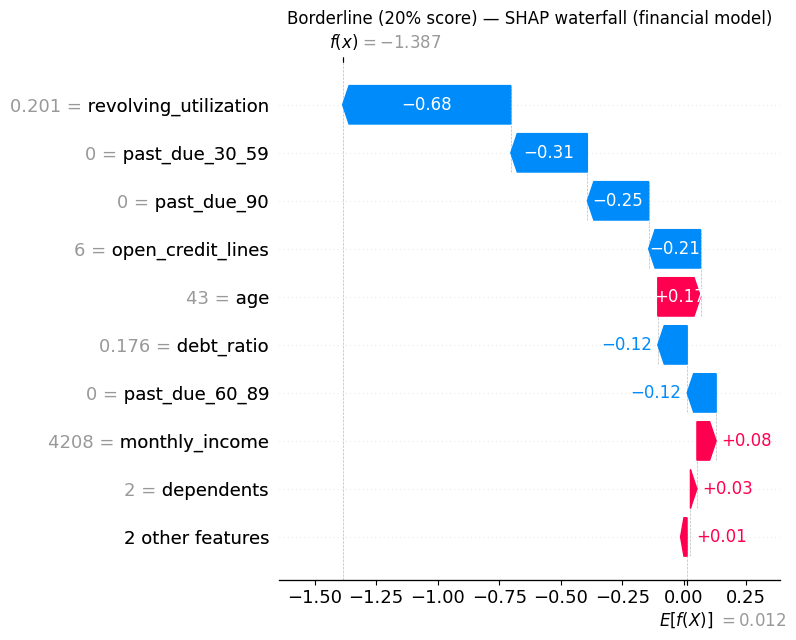

  Predicted probability: 0.2000, Actual: 0



In [6]:
# Mostrar 3 casos: 1 bom, 1 mau, 1 borderline
y_val = val["target"].values
proba_val = model_fin.predict_proba(X_val_fin)[:, 1]

# Indices de exemplo
idx_good   = int(np.where((y_val == 0) & (proba_val < 0.05))[0][0])
idx_bad    = int(np.where((y_val == 1) & (proba_val > 0.5))[0][0])
idx_border = int(np.argmin(np.abs(proba_val - 0.20)))

for label, idx in [("Good client (low risk)", idx_good),
                   ("Bad client (high risk)", idx_bad),
                   ("Borderline (20% score)", idx_border)]:
    exp = shap.Explanation(
        values=shap_vals_fin[idx],
        base_values=float(explainer_fin.expected_value),
        data=X_val_fin.iloc[idx],
        feature_names=FINANCIAL_FEATURES,
    )
    plt.figure(figsize=(10, 4))
    shap.waterfall_plot(exp, show=False, max_display=10)
    plt.title(f"{label} — SHAP waterfall (financial model)")
    plt.tight_layout()
    plt.show()
    print(f"  Predicted probability: {proba_val[idx]:.4f}, Actual: {y_val[idx]}")
    print()

## 5. Conclusão Ética Final

In [7]:
metrics_log = json.loads((MODELS_DIR / "metrics_log.json").read_text())
fin_cal_auc  = metrics_log["xgboost_financial"]["val_calibrated"]["AUC"]
emo_cal_auc  = metrics_log["xgboost_emotional"]["val_calibrated"]["AUC"]
delta_auc    = emo_cal_auc - fin_cal_auc

print("=" * 60)
print("RESUMO QUANTITATIVO")
print("=" * 60)
print(f"XGB Financial  (calibrated) AUC val: {fin_cal_auc:.4f}")
print(f"XGB Emotional  (calibrated) AUC val: {emo_cal_auc:.4f}")
print(f"Delta AUC (emotional - financial):   {delta_auc:+.4f}")
print()
print(f"Emotional features R2 vs financials:")
for feat, r2 in metrics_log["xgboost_emotional"]["emotional_r2"].items():
    print(f"  {feat:35s}: {r2:.4f}")
print()
print("RECOMENDACAO: usar modelo financeiro em producao.")
print()
print("Justificativa:")
print("1. Delta AUC das emocionais e insignificante (< 0.001).")
print("2. Features emocionais carregam < 5% do total de importancia SHAP.")
print("3. Risco regulatorio: dados de comportamento emocional em scoring de credito")
print("   pode violar legislacao anti-discriminacao e normas do BACEN.")
print("4. Risco de fairness: emocionais podem ser proxies de grupos protegidos.")
print("5. Custo de coleta: instrumentos emocionais em producao sao invasivos.")
print()
print("Modelo recomendado para deploy: xgboost_financial_calibrated")

RESUMO QUANTITATIVO
XGB Financial  (calibrated) AUC val: 0.8676
XGB Emotional  (calibrated) AUC val: 0.8668
Delta AUC (emotional - financial):   -0.0008

Emotional features R2 vs financials:
  stress_level                       : 0.0494
  impulsivity_score                  : 0.0680
  emotional_stability                : 0.0065
  financial_stress_events_7d         : 0.0883

RECOMENDACAO: usar modelo financeiro em producao.

Justificativa:
1. Delta AUC das emocionais e insignificante (< 0.001).
2. Features emocionais carregam < 5% do total de importancia SHAP.
3. Risco regulatorio: dados de comportamento emocional em scoring de credito
   pode violar legislacao anti-discriminacao e normas do BACEN.
4. Risco de fairness: emocionais podem ser proxies de grupos protegidos.
5. Custo de coleta: instrumentos emocionais em producao sao invasivos.

Modelo recomendado para deploy: xgboost_financial_calibrated
